In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/final_dataset.csv", parse_dates=["timestamp"])

prophet_df = df[["timestamp", "price"]].copy()
prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2023-01-01 00:00:00,-5.17
1,2023-01-01 01:00:00,-1.07
2,2023-01-01 02:00:00,-1.47
3,2023-01-01 03:00:00,-5.08
4,2023-01-01 04:00:00,-4.49


In [3]:
train = prophet_df[prophet_df["ds"] <= "2025-12-31"]
test = prophet_df[prophet_df["ds"] > "2025-12-31"]

In [4]:
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

Importing plotly failed. Interactive plots will not work.
21:52:28 - cmdstanpy - INFO - Chain [1] start processing
21:52:46 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
future = model.make_future_dataframe(periods=len(test), freq="h")

In [6]:
forecast = model.predict(future)

In [7]:
forecast_test = forecast.set_index("ds").loc[test["ds"]]

y_pred = forecast_test["yhat"].values
y_true = test["y"].values

In [8]:
from sklearn.metrics import mean_absolute_error

mae_prophet = mean_absolute_error(y_true, y_pred)

print("Prophet MAE:", mae_prophet)

Prophet MAE: 26.843455583461132


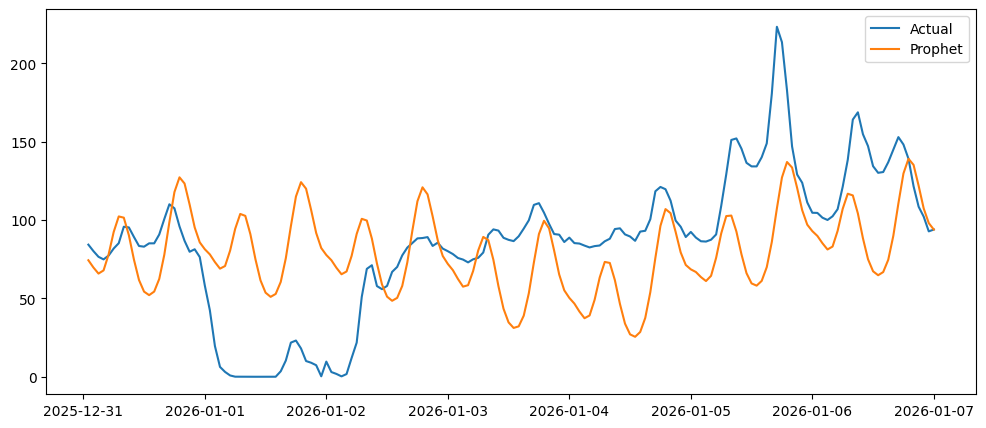

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test["ds"][:168], y_true[:168], label="Actual")
plt.plot(test["ds"][:168], y_pred[:168], label="Prophet")
plt.legend()
plt.show()